# Homework 2 - balancing, transformations, and dimensionality reduction (deadline 21. 12. 2025, 23:59)

In short, the main task is to play with balancing, binning, transformations, and dimensionality reduction to obtain the best results for the binary classification task.
  
> The instructions are not given in detail: It is up to you to come up with ideas on how to fulfill the particular tasks as best you can!

However, we **strongly recommend and require** the following:
* Follow the assignment step by step. Number each step.
* Properly comment on all your steps. Use Markdown cells and visualizations. Comments are evaluated for 2 points of the total, together with the final presentation of the solution. However, it is not desirable to write novels! 
* This task is timewise and computationally intensive. Do not leave it to the last minute.
* Most steps contain the number of features that should be treated. You can preprocess more features. However, it does not mean the teacher will give you more points. Focus on quality, not quantity.
* Hand in a notebook that has already been run (i.e., do not delete outputs before handing in).

## What are you supposed to do:

  1. Download the dataset [here](https://www.dropbox.com/s/aq08ytozfplb97b/data.csv?dl=0). Split the dataset into a train, validation, and test set and **use these parts correctly (!)** in the following steps.
  1. Choose at least one classification algorithm whose performance is to be improved in the following steps.
  1. Use at least two binning methods (on features of your choice, with your choice of parameters) and comment on their effects on classification performance. _I.e., one kind of classifier trained for each binning and a comparison of the effect of binning methods against each other._ _(4 points, depends on creativity)_ 
  1. Use at least two data balancing techniques on the correct part of the dataset and comment on its effects on classification performance. Focus on the comparison of methods between each other. _I.e., one type of classifier trained for each balancing and a comparison of the effect of balancing methods against each other._ **Just copied code from tutorial four will not be accepted.** _(6 points, depends on creativity)_
  1. Transform the features appropriately and prepare new ones (i.e., feature engineering) - focus on the increase in the model's performance (possibly in combination with further steps). _(5 points, depends on creativity)_ 
  1. Try to find some suitable subset of features - use at least two feature selection methods. Evaluate your choice on the validation set and discuss the influence. Do not use PCA (principal component analysis) in this step. Manual selection will not be accepted. _(4 points, depends on creativity)_
  1. Use PCA to reduce the dimensionality. Discuss the influence of the number of principal components. _(4 points)_
  1. Try to find the best combination of the previous steps and run final classification tests on the correct part of the dataset - first for the original data, second for the best-found combination of the previous preprocessing steps. Compare the results and discuss (give a comment, use graphs, and so on). _(5 points)_

All your steps, choices, and the following code **must be commented on!** For text comments (discussion, etc., not code comments), use **Markdown cells**. Comments are evaluated for _2 points_ together with the final presentation of the solution.

**If you do all this properly, you will obtain 30 points.**

### FAQ

* Select the appropriate metric to evaluate the classification results.
* In steps 2 and 3, you are comparing methods against each other, not their effect on unadjusted data. However, you can comment on that, too.
* You choose the subset of features only in step 2 because of the binning methods. In the other steps, you work with the whole dataset.

## Comments

  * Please follow the technical instructions from https://courses.fit.cvut.cz/NI-PDD/homeworks/index.html.
  * Methods that are more complex and were not shown during the tutorials are considered more creative and should be described in detail.
  * English is not compulsory.

  
## Data description

* The dataset can be downloaded [here](https://www.dropbox.com/s/aq08ytozfplb97b/data.csv?dl=0).
* The data are devoted to the binary classification task. The aim is to predict the probability that a driver will initiate an auto insurance claim next year.
* The target feature is called 'y' and signifies whether or not a claim was filed for that policyholder.
* To fulfill the task, one does not need to know the meaning of predictors.
* Predictors that belong to similar groupings are tagged as such in the feature names (e.g., ind, reg, car, calc). In addition, feature names include the postfix _bin_ to indicate binary features and the postfix _cat_ to indicate categorical features. Features without these designations are either continuous or ordinal. Values of -1 indicate that the feature was missing from the observation.
* While using [train_test_split](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html), control the shuffling of data by random_state parameter. Do not use shuffle=False, probably never (can cause systematic error).

# UTILS

In [2]:
# imports
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_auc_score, classification_report
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.preprocessing import KBinsDiscretizer

# 1. Load the dataset
Load the data and split it into train, validation, and test set

- the data is split into 60% train, 20% validation, and 20% test set
- use stratified splitting to maintain the class distribution in each set

In [3]:
data_path = "data/data.csv"

# Load the data
data = pd.read_csv(data_path)

In [4]:
# split the data into train, validation, and test set
X = data.drop(columns=['y'])
y = data['y']

# set -1 in X to NaN for easier handling of missing values
X = X.replace(-1, np.nan)

# split the data into 60% train, 20% validation, and 20% test set
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42, stratify=y)

# split the temp set into validation and test set
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

## Data exploration

In [4]:
# show basic info about the data
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 595212 entries, 0 to 595211
Data columns (total 58 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   y             595212 non-null  int64  
 1   xind_01       595212 non-null  int64  
 2   xind_02_cat   595212 non-null  int64  
 3   xind_03       595212 non-null  int64  
 4   xind_04_cat   595212 non-null  int64  
 5   xind_05_cat   595212 non-null  int64  
 6   xind_06_bin   595212 non-null  int64  
 7   xind_07_bin   595212 non-null  int64  
 8   xind_08_bin   595212 non-null  int64  
 9   xind_09_bin   595212 non-null  int64  
 10  xind_10_bin   595212 non-null  int64  
 11  xind_11_bin   595212 non-null  int64  
 12  xind_12_bin   595212 non-null  int64  
 13  xind_13_bin   595212 non-null  int64  
 14  xind_14       595212 non-null  int64  
 15  xind_15       595212 non-null  int64  
 16  xind_16_bin   595212 non-null  int64  
 17  xind_17_bin   595212 non-null  int64  
 18  xind

In [5]:
# describe data
data.describe()

,y,xind_01,xind_02_cat,xind_03,xind_04_cat,xind_05_cat,xind_06_bin,xind_07_bin,xind_08_bin,xind_09_bin,...,xcalc_11,xcalc_12,xcalc_13,xcalc_14,xcalc_15_bin,xcalc_16_bin,xcalc_17_bin,xcalc_18_bin,xcalc_19_bin,xcalc_20_bin
count,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,...,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000
mean,0.036448,1.900378,1.358943,4.423318,0.416794,0.405188,0.393742,0.257033,0.163921,0.185304,...,5.441382,1.441918,2.872288,7.539026,0.122427,0.627840,0.554182,0.287182,0.349024,0.153318
std,0.187401,1.983789,0.664594,2.699902,0.493311,1.350642,0.488579,0.436998,0.370205,0.388544,...,2.332871,1.202963,1.694887,2.746652,0.327779,0.483381,0.497056,0.452447,0.476662,0.360295
min,0.000000,0.000000,-1.000000,0.000000,-1.000000,-1.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,4.000000,1.000000,2.000000,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,1.000000,1.000000,4.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,5.000000,1.000000,3.000000,7.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000
75%,0.000000,3.000000,2.000000,6.000000,1.000000,0.000000,1.000000,1.000000,0.000000,0.000000,...,7.000000,2.000000,4.000000,9.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000
max,1.000000,7.000000,4.000000,11.000000,1.000000,6.000000,1.000000,1.000000,1.000000,1.000000,...,19.000000,10.000000,13.000000,23.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [7]:
# show how many values are missing in each column where -1 indicates missing value
missing_values = (data == -1).sum()
print("Missing values in each column:\n", missing_values)

Missing values in each column:
 y                    0
xind_01              0
xind_02_cat        216
xind_03              0
xind_04_cat         83
xind_05_cat       5809
xind_06_bin          0
xind_07_bin          0
xind_08_bin          0
xind_09_bin          0
xind_10_bin          0
xind_11_bin          0
xind_12_bin          0
xind_13_bin          0
xind_14              0
xind_15              0
xind_16_bin          0
xind_17_bin          0
xind_18_bin          0
xreg_01              0
xreg_02              0
xreg_03         107772
xcar_01_cat        107
xcar_02_cat          5
xcar_03_cat     411231
xcar_04_cat          0
xcar_05_cat     266551
xcar_06_cat          0
xcar_07_cat      11489
xcar_08_cat          0
xcar_09_cat        569
xcar_10_cat          0
xcar_11_cat          0
xcar_11              5
xcar_12              1
xcar_13              0
xcar_14          42620
xcar_15              0
xcalc_01             0
xcalc_02             0
xcalc_03             0
xcalc_04             0
xc

# 2. Classifier choice
Choose at least one classification algorithm whose performance is to be improved in the following steps.

**Model**
for this task, we will use **Logistic Regression** as our classification algorithms
    - the choice is motivated by its simplicity and interpretability and also it comutes faster, then for example Random Forest

 
**Metrics**

In this task , we will use the following metrics to evaluate the performance of our models:
- ROC AUC score: This metric is suitable for binary classification tasks and provides a measure of the model's ability to distinguish between the two classes.
- Classification report: This report provides detailed metrics such as precision, recall, and F1-score for each class, which helps in understanding the model's performance on both positive and negative classes.
- Confusion matrix: This visualization helps in understanding the types of errors made by the model, such as false positives and false negatives.

In [5]:
# identify categorical and numerical features
cat_cols = [c for c in X.columns if c.endswith('_cat')]
bin_cols = [c for c in X.columns if c.endswith('_bin')]
other_cols = [c for c in X.columns if c not in cat_cols + bin_cols]

numeric_preprocess = Pipeline([
    ('impute',    SimpleImputer(strategy='median')),
    ('scaler',    StandardScaler())
])

categorical_preprocess = Pipeline([
    ('impute',    SimpleImputer(strategy='most_frequent')),
    ('onehot',    OneHotEncoder(handle_unknown='ignore'))
])

preprocess = ColumnTransformer([
    ('num', numeric_preprocess, other_cols),
    ('bin', 'passthrough', bin_cols),
    ('cat', categorical_preprocess, cat_cols),
])

log_clf = LogisticRegression(
    n_jobs=-1
    , class_weight=None
)


In [6]:
def evaluate_pipeline(pipe, X_train, y_train, X_val, y_val, name="model"):
    """
    Fit the given pipeline, evaluate it on validation data,
    print metrics and show confusion matrix.
    """
    print(f"\n===== Evaluating: {name} =====")

    # fit
    pipe.fit(X_train, y_train)

    # predict
    y_val_pred_proba = pipe.predict_proba(X_val)[:, 1]
    y_val_pred = pipe.predict(X_val)

    # metrics
    auc = roc_auc_score(y_val, y_val_pred_proba)
    print(f"{name} ROC AUC: {auc:.4f}")
    print(classification_report(y_val, y_val_pred))

    # confusion matrix
    ConfusionMatrixDisplay.from_predictions(y_val, y_val_pred)
    plt.title(f"Confusion matrix: {name}")
    plt.show()

    return auc


===== Evaluating: Baseline Logistic Regression =====
Baseline Logistic Regression ROC AUC: 0.6358
              precision    recall  f1-score   support

           0       0.96      1.00      0.98    114703
           1       0.00      0.00      0.00      4339

    accuracy                           0.96    119042
   macro avg       0.48      0.50      0.49    119042
weighted avg       0.93      0.96      0.95    119042



/home/cernyf/.virtualenvs/default_env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/cernyf/.virtualenvs/default_env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/cernyf/.virtualenvs/default_env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"

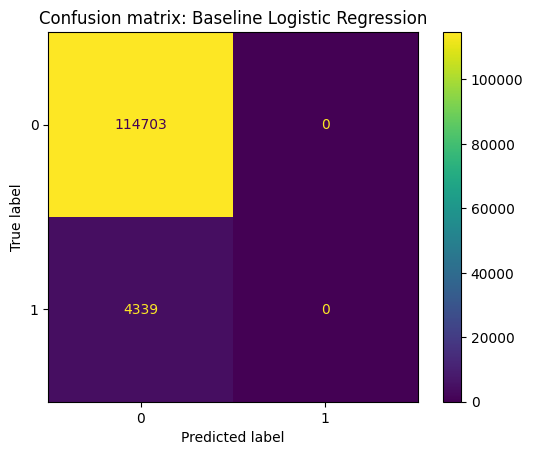

In [35]:
baseline_pipe = Pipeline([
    ('preprocess', preprocess),
    ('clf', log_clf)
])

# evaluate baseline model
baseline_auc = evaluate_pipeline(
    baseline_pipe,
    X_train, y_train,
    X_val, y_val,
    name="Baseline Logistic Regression"
)


From the baseline results we can see that our modeal can't properly classify the positive class. It never classifies any instance as positive. This is due to the class imbalance in the dataset, where the negative class is much more prevalent than the positive class.

# 3. Binning methods
Use at least two binning methods (on features of your choice, with your choice of parameters) and comment on their effects on classification performance. I.e., one kind of classifier trained for each binning and a comparison of the effect of binning methods against each other.

- We will apply equal-width binning to the all numerical, continues features in the dataset.
- We will use Sturges' formula to determine the number of bins: k = 1 + log2(n), where n is the number of observations.
    - which is approx. 20 bins for our dataset

Possible improvement:

- find for what features binning helps the most

In [7]:
# show me head of other columsn
print(X_train[other_cols].head())

        xind_01  xind_03  xind_14  xind_15  xreg_01  xreg_02   xreg_03  \
48913         2        3        0        7      0.9      1.2  1.543940   
360707        1        3        0        9      0.4      0.0  0.535607   
442580        6        7        0        6      0.6      0.2  0.642748   
63315         2        3        0        9      0.7      0.3  0.748749   
209390        0        3        1        4      0.8      0.2  0.494343   

        xcar_11   xcar_12   xcar_13  ...  xcalc_05  xcalc_06  xcalc_07  \
48913       3.0  0.424264  0.843081  ...         4         9         1   
360707      1.0  0.316070  0.598310  ...         2        10         2   
442580      1.0  0.316228  0.746811  ...         1         8         5   
63315       3.0  0.399875  0.680757  ...         1         9         4   
209390      2.0  0.316228  0.763947  ...         3        10         5   

        xcalc_08  xcalc_09  xcalc_10  xcalc_11  xcalc_12  xcalc_13  xcalc_14  
48913         10         4     

In [8]:
n_bins = 20

# select only other_cols for training and validation
X_train_other = X_train[other_cols]
X_val_other = X_val[other_cols]

## Basis result
- run the baseline logistic regression again for comparison only on the selected columns


===== Evaluating: Baseline Logistic Regression on selected columns =====
Baseline Logistic Regression on selected columns ROC AUC: 0.6030
              precision    recall  f1-score   support

           0       0.96      1.00      0.98    114703
           1       0.00      0.00      0.00      4339

    accuracy                           0.96    119042
   macro avg       0.48      0.50      0.49    119042
weighted avg       0.93      0.96      0.95    119042



/home/cernyf/.virtualenvs/default_env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/cernyf/.virtualenvs/default_env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/cernyf/.virtualenvs/default_env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"

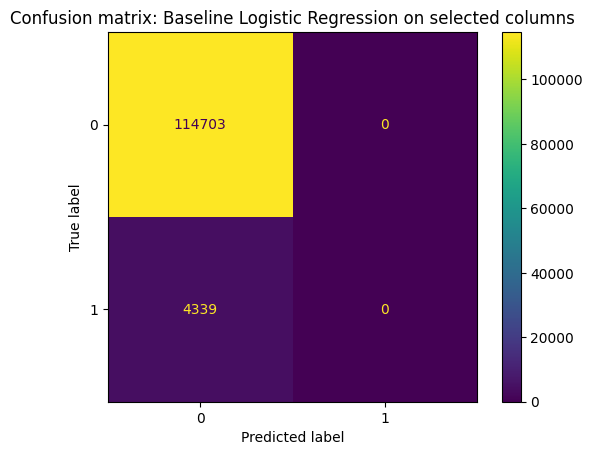

In [10]:

preprocess_basis = ColumnTransformer([
    ('num', numeric_preprocess, other_cols),
])

binning_basis_pipe = Pipeline([
    ('binning', preprocess_basis),
    ('clf', log_clf)
])

binning_basis_auc = evaluate_pipeline(
    binning_basis_pipe,
    X_train_other, y_train,
    X_val_other, y_val,
    name="Baseline Logistic Regression on selected columns"
)


## Binning method 1: Equal-width binning

### 20 bins


===== Evaluating: Binning Method 1: Equal-width binning =====
Binning Method 1: Equal-width binning ROC AUC: 0.6136
              precision    recall  f1-score   support

           0       0.96      1.00      0.98    114703
           1       0.00      0.00      0.00      4339

    accuracy                           0.96    119042
   macro avg       0.48      0.50      0.49    119042
weighted avg       0.93      0.96      0.95    119042



/home/cernyf/.virtualenvs/default_env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/cernyf/.virtualenvs/default_env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/cernyf/.virtualenvs/default_env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"

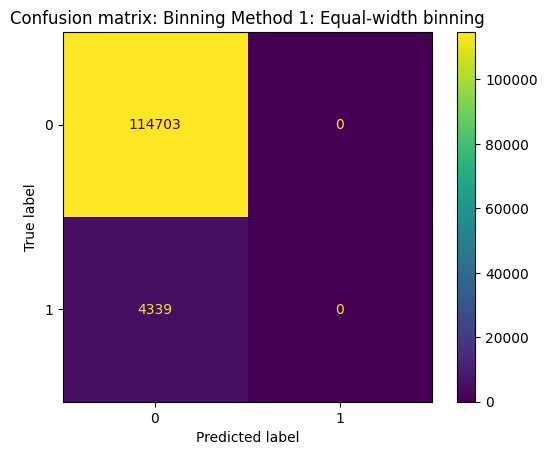

In [38]:

binning_A = ColumnTransformer([
    ('binned', Pipeline([
        ('impute', SimpleImputer(strategy='median')),
        ('bins', KBinsDiscretizer(n_bins=n_bins, encode='onehot-dense', strategy='uniform'))
    ]), other_cols)
])

binning_A_pipe = Pipeline([
    ('binning', binning_A),
    ('clf', log_clf)
])

# evaluate binning method 1
binning_A_auc = evaluate_pipeline(
    binning_A_pipe,
    X_train_other, y_train,
    X_val_other, y_val,
    name="Binning Method 1: Equal-width binning"
)

### 5 bins


===== Evaluating: Binning Method 1: Equal-width binning =====
Binning Method 1: Equal-width binning ROC AUC: 0.5997
              precision    recall  f1-score   support

           0       0.96      1.00      0.98    114703
           1       0.00      0.00      0.00      4339

    accuracy                           0.96    119042
   macro avg       0.48      0.50      0.49    119042
weighted avg       0.93      0.96      0.95    119042



/home/cernyf/.virtualenvs/default_env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/cernyf/.virtualenvs/default_env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/cernyf/.virtualenvs/default_env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"

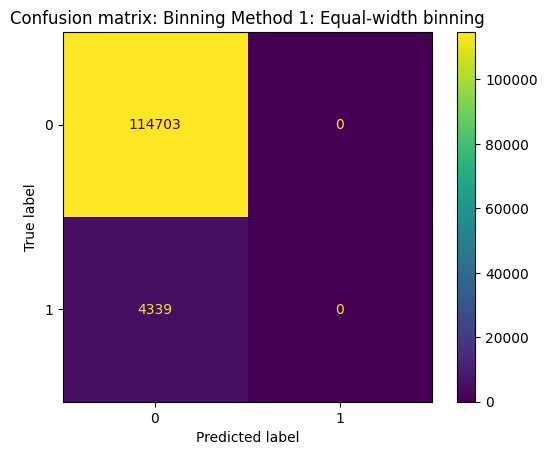

In [41]:

binning_A = ColumnTransformer([
    ('binned', Pipeline([
        ('impute', SimpleImputer(strategy='median')),
        ('bins', KBinsDiscretizer(n_bins=5, encode='onehot-dense', strategy='uniform'))
    ]), other_cols)
])

binning_A_pipe = Pipeline([
    ('binning', binning_A),
    ('clf', log_clf)
])

# evaluate binning method 1
binning_A_auc = evaluate_pipeline(
    binning_A_pipe,
    X_train_other, y_train,
    X_val_other, y_val,
    name="Binning Method 1: Equal-width binning"
)

## Binning method 2: Equal-frequency binning

### 20 bins


===== Evaluating: Binning Method 2: Equal-frequency binning =====


/home/cernyf/.virtualenvs/default_env/lib/python3.12/site-packages/sklearn/preprocessing/_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
/home/cernyf/.virtualenvs/default_env/lib/python3.12/site-packages/sklearn/preprocessing/_discretization.py:397: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 0 are removed. Consider decreasing the number of bins.
  warnings.warn(
/home/cernyf/.virtualenvs/default_env/lib/python3.12/site-packages/sklearn/preprocessing/_discretization.py:397: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 1 are removed. Consider decreasing the number of bins.
  warnings.warn(
/home/cernyf/.virtualenvs/default_env/lib/python3

Binning Method 2: Equal-frequency binning ROC AUC: 0.6146
              precision    recall  f1-score   support

           0       0.96      1.00      0.98    114703
           1       0.00      0.00      0.00      4339

    accuracy                           0.96    119042
   macro avg       0.48      0.50      0.49    119042
weighted avg       0.93      0.96      0.95    119042



/home/cernyf/.virtualenvs/default_env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/cernyf/.virtualenvs/default_env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/cernyf/.virtualenvs/default_env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"

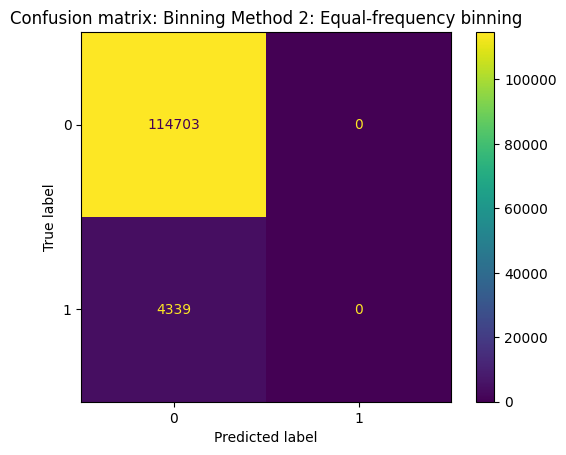

In [39]:
binning_B = ColumnTransformer([
    ('binned', Pipeline([
        ('impute', SimpleImputer(strategy='median')),
        ('bins', KBinsDiscretizer(n_bins=n_bins, encode='onehot-dense', strategy='quantile'))
    ]), other_cols)
])
binning_B_pipe = Pipeline([
    ('binning', binning_B),
    ('clf', log_clf)
])
# evaluate binning method 2
binning_B_auc = evaluate_pipeline(
    binning_B_pipe,
    X_train_other, y_train,
    X_val_other, y_val,
    name="Binning Method 2: Equal-frequency binning"
)

### 5 bins


===== Evaluating: Binning Method 2: Equal-frequency binning =====


/home/cernyf/.virtualenvs/default_env/lib/python3.12/site-packages/sklearn/preprocessing/_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
/home/cernyf/.virtualenvs/default_env/lib/python3.12/site-packages/sklearn/preprocessing/_discretization.py:397: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 0 are removed. Consider decreasing the number of bins.
  warnings.warn(
/home/cernyf/.virtualenvs/default_env/lib/python3.12/site-packages/sklearn/preprocessing/_discretization.py:397: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 2 are removed. Consider decreasing the number of bins.
  warnings.warn(
/home/cernyf/.virtualenvs/default_env/lib/python3

Binning Method 2: Equal-frequency binning ROC AUC: 0.6080
              precision    recall  f1-score   support

           0       0.96      1.00      0.98    114703
           1       0.00      0.00      0.00      4339

    accuracy                           0.96    119042
   macro avg       0.48      0.50      0.49    119042
weighted avg       0.93      0.96      0.95    119042



/home/cernyf/.virtualenvs/default_env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/cernyf/.virtualenvs/default_env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/cernyf/.virtualenvs/default_env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"

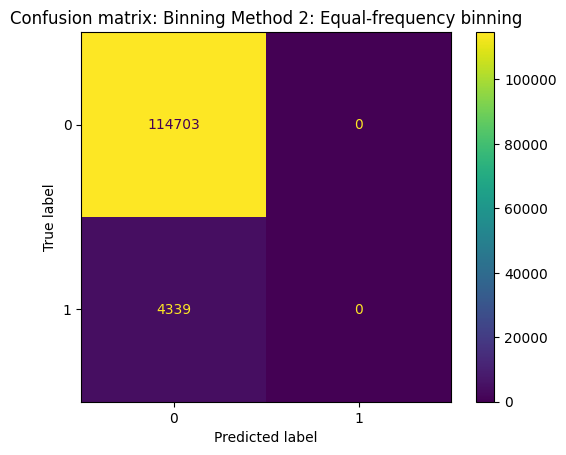

In [42]:
binning_B = ColumnTransformer([
    ('binned', Pipeline([
        ('impute', SimpleImputer(strategy='median')),
        ('bins', KBinsDiscretizer(n_bins=5, encode='onehot-dense', strategy='quantile'))
    ]), other_cols)
])
binning_B_pipe = Pipeline([
    ('binning', binning_B),
    ('clf', log_clf)
])
# evaluate binning method 2
binning_B_auc = evaluate_pipeline(
    binning_B_pipe,
    X_train_other, y_train,
    X_val_other, y_val,
    name="Binning Method 2: Equal-frequency binning"
)

## COMPARISON

**Baseline result**

```
==== Evaluating: Baseline Logistic Regression on selected columns =====
Baseline Logistic Regression on selected columns ROC AUC: 0.6030
              precision    recall  f1-score   support

           0       0.96      1.00      0.98    114703
           1       0.00      0.00      0.00      4339

    accuracy                           0.96    119042
   macro avg       0.48      0.50      0.49    119042
weighted avg       0.93      0.96      0.95    119042
```


**20 bins**


```

===== Evaluating: Binning Method 1: Equal-width binning =====
Binning Method 1: Equal-width binning ROC AUC: 0.6136
              precision    recall  f1-score   support

           0       0.96      1.00      0.98    114703
           1       0.00      0.00      0.00      4339

    accuracy                           0.96    119042
   macro avg       0.48      0.50      0.49    119042
weighted avg       0.93      0.96      0.95    119042
```

```

===== Evaluating: Binning Method 2: Equal-frequency binning =====

Binning Method 2: Equal-frequency binning ROC AUC: 0.6146
              precision    recall  f1-score   support

           0       0.96      1.00      0.98    114703
           1       0.00      0.00      0.00      4339

    accuracy                           0.96    119042
   macro avg       0.48      0.50      0.49    119042
weighted avg       0.93      0.96      0.95    119042
```

**5 bins**

```

===== Evaluating: Binning Method 1: Equal-width binning =====
Binning Method 1: Equal-width binning ROC AUC: 0.5997
              precision    recall  f1-score   support

           0       0.96      1.00      0.98    114703
           1       0.00      0.00      0.00      4339

    accuracy                           0.96    119042
   macro avg       0.48      0.50      0.49    119042
weighted avg       0.93      0.96      0.95    119042
```

```
Binning Method 2: Equal-frequency binning ROC AUC: 0.6080
              precision    recall  f1-score   support

           0       0.96      1.00      0.98    114703
           1       0.00      0.00      0.00      4339

    accuracy                           0.96    119042
   macro avg       0.48      0.50      0.49    119042
weighted avg       0.93      0.96      0.95    119042
```


We can see an improvement in AUC values for using 20 or 5 bins when using Equal-width binning vs Equal-frequancy binning there is an improvement around 0,001 for Equal-frequency binning. 

With comparison with an baseline model, with 20 bins we can see an improvement around 0,01 in AUC values for both binning methods and with 5 bins we can see an decrease around 0,003 in AUC values or staying the same.